In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import joblib

In [5]:
df = pd.read_csv("../data/cleaned_dataset.csv")
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,3,65.0,8450,1,3,3,0,4,0,...,0,0,0,0,0,2,2008,8,4,208500
1,20,3,80.0,9600,1,3,3,0,2,0,...,0,0,0,0,0,5,2007,8,4,181500
2,60,3,68.0,11250,1,0,3,0,4,0,...,0,0,0,0,0,9,2008,8,4,223500
3,70,3,60.0,9550,1,0,3,0,0,0,...,272,0,0,0,0,2,2006,8,0,140000
4,60,3,84.0,14260,1,0,3,0,2,0,...,0,0,0,0,0,12,2008,8,4,250000


In [6]:
print("Shape:", df.shape)
print("\nMissing values:", df.isnull().sum().sum())
df.info()

Shape: (1460, 74)

Missing values: 0
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 74 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   int64  
 2   LotFrontage    1460 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   int64  
 5   LotShape       1460 non-null   int64  
 6   LandContour    1460 non-null   int64  
 7   Utilities      1460 non-null   int64  
 8   LotConfig      1460 non-null   int64  
 9   LandSlope      1460 non-null   int64  
 10  Neighborhood   1460 non-null   int64  
 11  Condition1     1460 non-null   int64  
 12  Condition2     1460 non-null   int64  
 13  BldgType       1460 non-null   int64  
 14  HouseStyle     1460 non-null   int64  
 15  OverallQual    1460 non-null   int64  
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-nu

In [7]:
#Separate Features & Target
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [8]:
#Handle Categorical Variables
X = pd.get_dummies(X, drop_first=True)
print("Shape after encoding:", X.shape)

Shape after encoding: (1460, 73)


In [9]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
#Linear Regression (Baseline Model)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Linear Regression Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression Performance:
MAE: 21230.215213529053
R2 Score: 0.8479380949127464


In [11]:
#Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\nRandom Forest Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))


Random Forest Performance:
MAE: 17512.70726027397
R2 Score: 0.8998538908489729


In [12]:
#XGBoost Model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("\nXGBoost Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("R2 Score:", r2_score(y_test, y_pred_xgb))


XGBoost Performance:
MAE: 16178.8818359375
R2 Score: 0.9152373671531677


In [13]:
#Model Comparison
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb)
    ],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb)
    ]
})

results.sort_values(by="R2 Score", ascending=False)

,Model,MAE,R2 Score
2,XGBoost,16178.881836,0.915237
1,Random Forest,17512.707260,0.899854
0,Linear Regression,21230.215214,0.847938


In [14]:
#Save Best Model
joblib.dump(xgb_model, "../model/house_price_model.pkl")

['../model/house_price_model.pkl']

In [15]:
#Load Model (Test Saving)
loaded_model = joblib.load("../model/house_price_model.pkl")

sample_pred = loaded_model.predict(X_test.iloc[:5])
print("Sample Predictions:", sample_pred)

Sample Predictions: [142802.34 331884.66 109977.56 174476.55 299365.06]


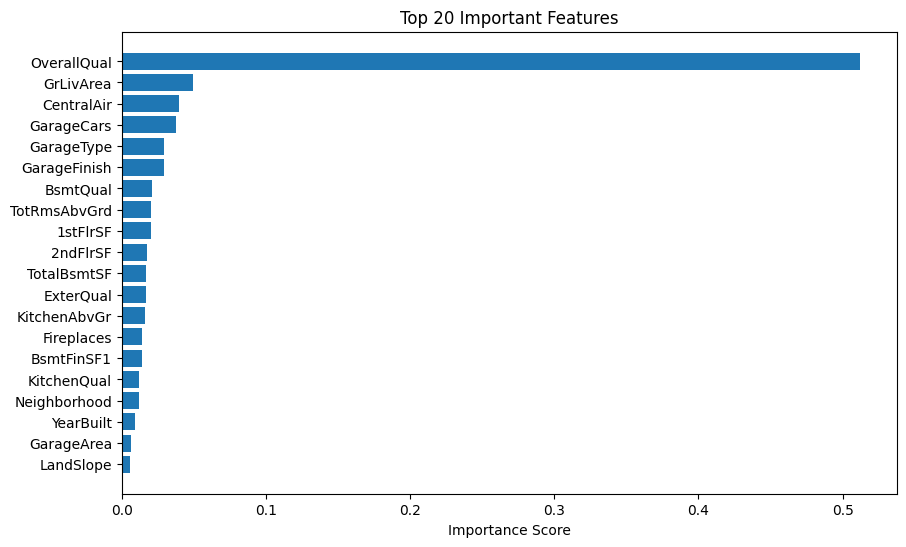

In [16]:
#Feature Importance

import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance
importances = xgb_model.feature_importances_
features = X.columns

# Create dataframe
feature_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot top 20
plt.figure(figsize=(10,6))
plt.barh(feature_importance_df["Feature"][:20], feature_importance_df["Importance"][:20])
plt.gca().invert_yaxis()
plt.title("Top 20 Important Features")
plt.xlabel("Importance Score")
plt.show()